<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL3_traditional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for an image dataset (CIFAR-10). To run this notebook, do the following:
1. First click the Colab `Run all` button. Due to some library conflicts you will need to restart session in the first cell below.
2. After that click `Run all` again (library installation and dataset loading are automated).
3. Select the confiuration you want in the last cell (default: ResNet50 feature extractor with PCA-256 for Logistic Regression).
4. After that click `Run Pipeline` in the last cell. The pipeline will run according to your configuration.

If you want to rerun the pipeline with another configuration, you need to rerun the last cell and then repeat from step 3.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [1]:
# !pip install --quiet timm==0.6.12
!pip install --quiet timm
!pip install --quiet ipywidgets
!pip install --quiet kaleido
!pip install --quiet huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.4 MB/s eta 0:00:00


In [2]:
import os
import time
import math
import random
import json
from pathlib import Path
from collections import Counter
from itertools import product as iter_product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10

import timm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
from huggingface_hub import hf_hub_download, HfApi


# For widgets
import ipywidgets as widgets
from IPython.display import display, clear_output

# For progress bars
from tqdm.notebook import tqdm

# Utilities
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# Ensure reproducibility
RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

ROOT = Path('.').absolute()
FEATURE_ROOT = ROOT / 'features'
FEATURE_ROOT.mkdir(exist_ok=True)

REPO_ID = 'LeTienDat/BTL3_CIFAR-10'
HYPERPARAMS_FILE = 'tuned_hyperparams.json'
RESULTS_FILE = 'comparison_results.json'

Device: cpu


## 1.2.&nbsp;Download and store the dataset

In [3]:
def get_datasets(download_root='data', val_split_ratio=0.1):
    download_root = Path(download_root)
    download_root.mkdir(parents=True, exist_ok=True)

    transform_raw = transforms.Compose([transforms.ToTensor()])
    full_train = CIFAR10(root=str(download_root), train=True, download=True, transform=transform_raw)
    test_set = CIFAR10(root=str(download_root), train=False, download=True, transform=transform_raw)

    # Create stratified validation split from train
    train_indices, val_indices, train_labels, val_labels = train_test_split(
        range(len(full_train)),
        full_train.targets,
        test_size=val_split_ratio,
        stratify=full_train.targets,
        random_state=RND
    )

    train_set = Subset(full_train, train_indices)
    val_set = Subset(full_train, val_indices)

    return train_set, val_set, test_set

train_set, val_set, test_set = get_datasets()
# Add printing image shape and data type
sample_img, _ = train_set[0]
print(f"Image shape: {sample_img.shape}, Image dtype: {sample_img.dtype}")
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

# helper to get class names
_CIFAR10_CLASSES = train_set.dataset.classes if isinstance(train_set, Subset) else train_set.dataset.classes
print('Classes:', _CIFAR10_CLASSES)

100%|██████████| 170M/170M [00:04<00:00, 40.7MB/s]


Image shape: torch.Size([3, 32, 32]), Image dtype: torch.float32
Train: 45000, Val: 5000, Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# 2.&nbsp;Exploratory Data Analysis (EDA)

--- TRAIN ---


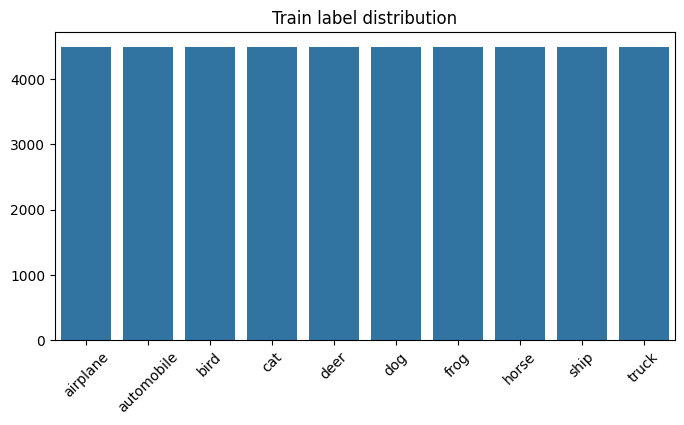

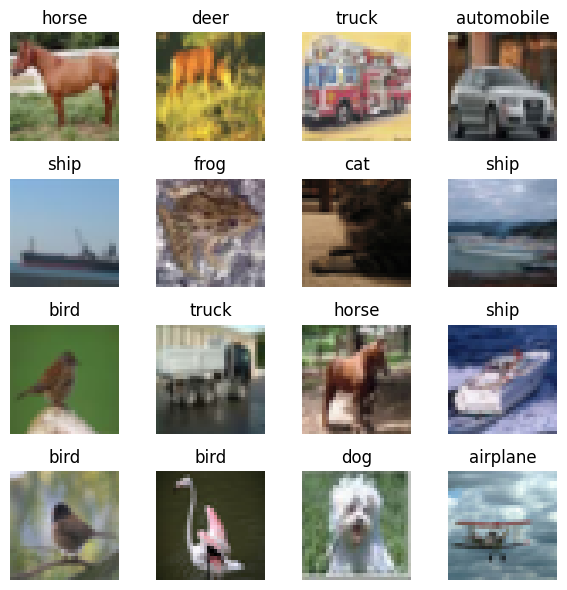

--- VAL ---


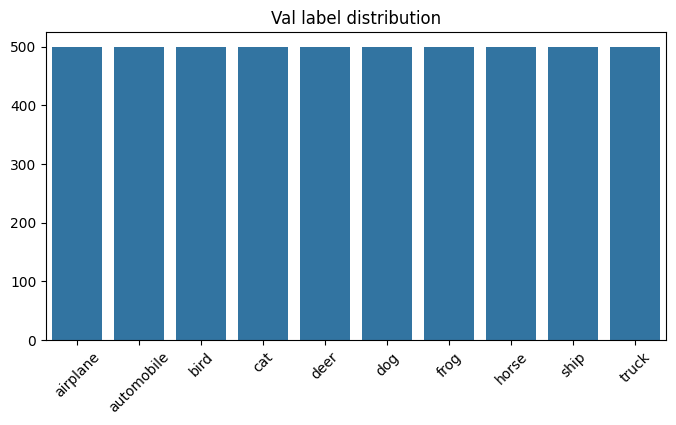

--- TEST ---


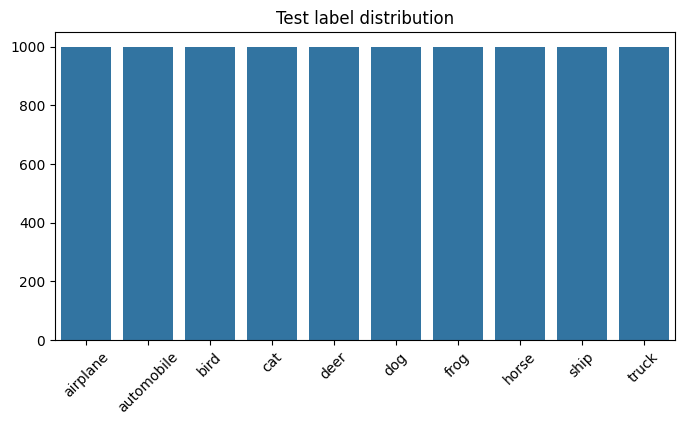

In [4]:
def show_label_distribution(dataset, title='Label distribution'):
    labels = []
    if isinstance(dataset, Subset):
        for idx in dataset.indices:
            labels.append(dataset.dataset.targets[idx])
    else:
        labels = dataset.targets
    counter = Counter(labels)
    xs = [ _CIFAR10_CLASSES[i] for i in sorted(counter.keys())]
    ys = [ counter[i] for i in sorted(counter.keys())]
    plt.figure(figsize=(8,4))
    sns.barplot(x=xs, y=ys)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


def show_sample_grid(dataset, n=16, resize=None):
    fig, axes = plt.subplots(int(math.sqrt(n)), int(math.sqrt(n)), figsize=(6,6))
    axes = axes.flatten()
    rng = np.random.default_rng()
    idxs = rng.choice(len(dataset), size=n, replace=False)
    for ax, i in zip(axes, idxs):
        img, label = dataset[i]
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        if resize is not None:
            img = img.resize((resize, resize))
        ax.imshow(np.asarray(img))
        ax.set_title(_CIFAR10_CLASSES[label])
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def eda_report(train_set, val_set, test_set):
    print('--- TRAIN ---')
    show_label_distribution(train_set, 'Train label distribution')
    show_sample_grid(train_set, n=16)
    print('--- VAL ---')
    show_label_distribution(val_set, 'Val label distribution')
    print('--- TEST ---')
    show_label_distribution(test_set, 'Test label distribution')

# Run a quick EDA by default
eda_report(train_set, val_set, test_set)

# 3.&nbsp;Data Processing

## 3.1.&nbsp;Image Normalization

In [ ]:
# Default normalization in torchvision models: ImageNet mean/std
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transform(resize=224):
    return transforms.Compose([
        transforms.Resize((resize, resize)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

## 3.2.&nbsp;Feature Extraction

In [6]:
# Model factory for feature extractors
MODEL_CHOICES = {
    'VGG16': dict(source='torchvision', name='vgg16'),
    'ResNet50': dict(source='torchvision', name='resnet50'),
    'EfficientNet-B0': dict(source='torchvision', name='efficientnet_b0'),
    'ViT': dict(source='timm', name='vit_base_patch16_224'),
    'SwinTransformer': dict(source='timm', name='swin_base_patch4_window7_224')
}

DEFAULT_BATCH_SIZES = {
    'VGG16': 16,
    'ResNet50': 64,
    'EfficientNet-B0': 128,
    'ViT': 16,
    'SwinTransformer': 32
}

# Maximum batch size slider limits (can adjust based on GPU)
MAX_BATCH_SIZES = {
    'VGG16': 64,
    'ResNet50': 128,
    'EfficientNet-B0': 256,
    'ViT': 32,
    'SwinTransformer': 64
}

def create_feature_extractor(model_key, device=DEVICE):
    """Return a model that outputs feature vectors (1D per image)
       We'll strip classification heads when possible and avgpool.
    """
    info = MODEL_CHOICES[model_key]
    if info['source'] == 'torchvision':
        if info['name'] == 'vgg16':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1).to(device)
            model.classifier = model.classifier[:1]  # keep only fc6
            model.eval()
            def forward_fn(x):
                with torch.no_grad():
                    feat = model.features(x)
                    feat = model.avgpool(feat)
                    feat = torch.flatten(feat, 1)
                    feat = model.classifier(feat)  # fc6
                return feat
            feat_dim = 4096
            return forward_fn, feat_dim
        elif info['name'] == 'resnet50':
            model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1).to(device)
            # Remove fc
            model.fc = nn.Identity()
            model.eval()
            def forward_fn(x):
                with torch.no_grad():
                    feat = model(x)
                    feat = feat.view(feat.size(0), -1)
                return feat
            feat_dim = 2048
            return forward_fn, feat_dim
        elif info['name'] == 'efficientnet_b0':
            model = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1).to(device)
            model.classifier = nn.Identity()
            model.eval()
            def forward_fn(x):
                with torch.no_grad():
                    feat = model(x)
                    feat = torch.flatten(feat, 1)
                return feat
            feat_dim = 1280
            return forward_fn, feat_dim
    else:
        # use timm
        model = timm.create_model(info['name'], pretrained=True, num_classes=0, global_pool='avg').to(device)
        model.eval()
        def forward_fn(x):
            with torch.no_grad():
                feat = model(x)
            return feat
        # try to get feature dim
        feat_dim = model.num_features if hasattr(model, 'num_features') else None
        return forward_fn, feat_dim

## 3.3.&nbsp;Data Preprocessing Pipeline
Features are loaded if saved, otherwise re-extract.

In [7]:
# Feature extraction pipeline
def dataset_to_dataloader(dataset, transform, batch_size=64, num_workers=2):
    """Wrap dataset with transform and return DataLoader"""
    # Create a copy of dataset that applies transform on the fly
    class _Wrapped(torch.utils.data.Dataset):
        def __init__(self, ds, transform):
            self.ds = ds
            self.transform = transform
        def __len__(self):
            return len(self.ds)
        def __getitem__(self, idx):
            img, label = self.ds[idx]
            if not isinstance(img, Image.Image):
                img = transforms.ToPILImage()(img)
            img = self.transform(img)
            return img, label
    wrapped = _Wrapped(dataset, transform)
    return DataLoader(wrapped, batch_size=batch_size, shuffle=False, num_workers=num_workers)

def file_exists_in_repo(repo_id, path, repo_type="dataset"):
    api = HfApi()
    files = api.list_repo_files(repo_id=repo_id, repo_type=repo_type)
    return path in files

def extract_features_for_split(split_name, dataset, model_key, resize=224, batch_size=64, force_reextract=False, repo_id=None):
    """Extract (or load if exist) features for a split (train/val/test)
       returns X (numpy), y (numpy), feature_path
    """
    feature_dir = FEATURE_ROOT / model_key
    feature_dir.mkdir(parents=True, exist_ok=True)

    feat_file = feature_dir / f'{split_name}_features.npz'
    remote_path = f'{model_key}/{split_name}_features.npz'

    # Check if feature file exists locally or in repo
    if feat_file.exists() and (not force_reextract):
        print(f'Loading cached features: {feat_file}')
        loader = np.load(feat_file)
        return loader['X'], loader['y'], feat_file
    elif file_exists_in_repo(repo_id, remote_path, repo_type="dataset"):
        try:
            print(f'Downloading features from repo: {repo_id}/{remote_path}')
            path = hf_hub_download(
                repo_id=repo_id,
                filename=f"{model_key}/{split_name}_features.npz",
                repo_type="dataset",
                local_dir=FEATURE_ROOT,
            )
            print(f'Downloaded features to: {path}')
            loader = np.load(path)
            return loader['X'], loader['y'], feat_file
        except Exception as e:
            print(f"Could not download features from repo: {e}")
            print("Proceeding with feature extraction...")

    # else extract
    print('Creating transform...')
    transform = build_transform(resize)
    dl = dataset_to_dataloader(dataset, transform, batch_size=batch_size)
    forward_fn, feat_dim = create_feature_extractor(model_key)
    if feat_dim is None:
        # we will infer dynamically
        pass

    Xs = []
    Ys = []
    start = time.time()
    print(f'Extracting features for {split_name}...')
    for imgs, labels in tqdm(dl, desc=f'Extracting {split_name} features'):
        imgs = imgs.to(DEVICE)
        feats = forward_fn(imgs)
        feats = feats.detach().cpu().numpy()
        Xs.append(feats)
        Ys.append(np.array(labels))
    X = np.vstack(Xs)
    y = np.concatenate(Ys)
    duration = time.time() - start
    print(f'Extracted features for {split_name} shape={X.shape} in {duration:.1f}s')

    np.savez_compressed(feat_file, X=X, y=y)
    return X, y, feat_file

## 3.4.&nbsp;Post-processing
Scaler and PCA

In [8]:
def fit_scaler_and_pca(X_train, use_pca=True, pca_dim=256):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_train)
    pca = None
    if use_pca:
        pca = PCA(n_components=min(pca_dim, Xs.shape[1]))
        Xs = pca.fit_transform(Xs)
    return scaler, pca, Xs

def transform_with_scaler_pca(X, scaler, pca=None):
    Xs = scaler.transform(X)
    if pca is not None:
        Xs = pca.transform(Xs)
    return Xs

# 4.&nbsp;Training and Evaluation

In [9]:
CLASSIFIERS = {
    'LogisticRegression': LogisticRegression,
    'LinearSVM': LinearSVC,
    'RandomForest': RandomForestClassifier,
    'k-NN': KNeighborsClassifier,
    'ShallowMLP': MLPClassifier
}

HYPERPARAM_GRIDS = {
    'LogisticRegression': {'C': [0.001, 0.01, 0.1, 1.0, 10.0]},
    'LinearSVM': {'C': [0.1, 1.0, 10.0]},
    'RandomForest': {'n_estimators': [100,200], 'max_depth': [None,20,50]},
    'k-NN': {'n_neighbors': [3,5,7]},
    'ShallowMLP': {'hidden_layer_sizes': [(512,), (1024,)], 'alpha':[1e-4, 1e-3]}
}

def create_classifier(name, **kwargs):
    if name == 'LogisticRegression':
        return LogisticRegression(solver='saga', max_iter=1000, random_state=RND, **kwargs)
    if name == 'LinearSVM':
        return LinearSVC(**kwargs)
    if name == 'RandomForest':
        return RandomForestClassifier(**kwargs)
    if name == 'k-NN':
        return KNeighborsClassifier(**kwargs)
    if name == 'ShallowMLP':
        return MLPClassifier(max_iter=1000, random_state=RND, **kwargs)
    raise ValueError('Unknown classifier')

# train + evaluate wrapper
def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test, clf_name, clf_kwargs):
    # Combine train and val to train
    X_train_combined = np.concatenate((X_train, X_val), axis=0)
    y_train_combined = np.concatenate((y_train, y_val), axis=0)

    clf = create_classifier(clf_name, **clf_kwargs)
    print(f'Training {clf_name}...')
    t0 = time.time()
    clf.fit(X_train_combined, y_train_combined)
    train_time = time.time() - t0
    print(f'Training finished in {train_time:.2f}s.')

    print(f'Evaluating {clf_name}...')
    t0 = time.time()
    preds = clf.predict(X_test)
    predict_time = time.time() - t0
    print(f'Evaluation finished in {predict_time:.4f}s.')

    acc = accuracy_score(y_test, preds)
    rep = classification_report(y_test, preds, target_names=_CIFAR10_CLASSES, digits=4)
    cm = confusion_matrix(y_test, preds)
    return dict(clf=clf, acc=acc, report=rep, cm=cm, train_time=train_time, predict_time=predict_time, preds=preds)

# 5.&nbsp;Visualization

In [10]:
def plot_confusion_matrix(cm, labels=_CIFAR10_CLASSES, figsize=(10,8)):
    plt.figure(figsize=figsize)
    plt.title('Confusion Matrix')
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_comparison_results(df):
    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x='Feature Model', y='Accuracy', hue='Classifier')
    plt.title('Model Comparison (with PCA options)')
    plt.ylim(0.7, 1.0)
    plt.show()

    plt.figure(figsize=(6,5))
    plt.scatter(df['Inference Time'], df['Accuracy'])
    plt.xlabel('Inference Time'); plt.ylabel('Accuracy')
    plt.title('Inference Time vs Accuracy')
    plt.show()

# 5.&nbsp;Combined Pipeline

In [11]:
def run_pipeline(config):
    """config: dict with keys:
       - resize
       - model_name
       - repo_path
       - pca (bool), pca_dim
       - classifier_name, classifier_kwargs
    """
    print('Running pipeline with config:', config)

    model_key = config['model_name']
    resize = config['resize']
    batch_size = config['batch_size']
    # extract/load features
    X_train, y_train, ftrain = extract_features_for_split('train', train_set, model_key, resize, batch_size, repo_id=REPO_ID)
    X_val, y_val, fval = extract_features_for_split('val', val_set, model_key, resize, batch_size, repo_id=REPO_ID)
    X_test, y_test, ftest = extract_features_for_split('test', test_set, model_key, resize, batch_size, repo_id=REPO_ID)

    # Postprocess
    use_pca = config['pca']
    pca_dim = config['pca_dim']
    scaler, pca, X_train_proc = fit_scaler_and_pca(X_train, use_pca, pca_dim)
    X_val_proc = transform_with_scaler_pca(X_val, scaler, pca)
    X_test_proc = transform_with_scaler_pca(X_test, scaler, pca)

    # Train classifier
    clf_name = config['classifier_name']
    clf_kwargs = config.get('classifier_kwargs', {})
    results = train_and_evaluate(X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test, clf_name, clf_kwargs)

    return results

# 6.&nbsp;Comparison Pipeline

## 6.1.&nbsp;Hyperparameter Tuning

In [12]:
def tune_hyperparameters(X_train, y_train, X_val, y_val, clf_name):
    grid = HYPERPARAM_GRIDS[clf_name]
    keys, values = zip(*grid.items())
    best_acc = -1
    best_params = {}

    for combo in iter_product(*values):
        params = dict(zip(keys, combo))
        clf = create_classifier(clf_name, **params)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_val)
        acc = accuracy_score(y_val, preds)
        if acc > best_acc:
            best_acc = acc
            best_params = params
    return best_params, best_acc

def load_tuned_hyperparams(repo_id=REPO_ID, filename=HYPERPARAMS_FILE):
    """Try loading tuned hyperparameters locally or from Hugging Face dataset."""
    local_path = ROOT / filename
    if os.path.exists(local_path):
        print(f"Loaded local tuned hyperparameters from {local_path}")
        with open(local_path, "r") as f:
            return json.load(f)
    if file_exists_in_repo(repo_id, local_path, repo_type="dataset"):
        try:
            path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset", local_dir=ROOT)
            with open(path, "r") as f:
                print(f"Loaded tuned hyperparameters from repo: {repo_id}/{filename}")
                return json.load(f)
        except Exception as e:
            print(f"Could not load tuned hyperparameters from repo: {e}")
    print(f"No tuned hyperparameters found.")
    return {}

def save_tuned_hyperparams(tuned_hyperparams, filename=HYPERPARAMS_FILE):
    """Save tuned hyperparameters locally and push to Hugging Face if desired."""
    local_path = ROOT / filename
    with open(local_path, "w") as f:
        json.dump(tuned_hyperparams, f, indent=2)
    print(f"Tuned hyperparameters saved to {local_path}")
    return local_path

## 6.2.&nbsp;Comparison Pipeline

In [13]:
def run_comparison():
    results = []
    pca_options = [True, False]
    tuned_hyperparams = load_tuned_hyperparams(REPO_ID)
    tuned_hyperparams_updated = False

    for m, c in iter_product(MODEL_CHOICES.keys(), CLASSIFIERS.keys()):
        best_overall_acc = -1
        best_overall_params = {}
        best_overall_pca = None
        best_result_dict = None

        key = f"{m}|{c}"

        if key in tuned_hyperparams:
            print(f"\n✅ Using pre-tuned hyperparameters for {m} + {c}")
            entry = tuned_hyperparams[key]
            best_overall_params = entry['params']
            if c == 'ShallowMLP': # fix json list -> shape
                best_overall_params['hidden_layer_sizes'] = (int(best_overall_params['hidden_layer_sizes'][0]),)
            best_overall_pca = entry.get('pca', True)

            cfg = dict(resize=224, model_name=m, pca=best_overall_pca, pca_dim=256,
                       classifier_name=c, classifier_kwargs=best_overall_params)

            # Extract/load features
            X_train, y_train, _ = extract_features_for_split('train', train_set, m, cfg['resize'], batch_size=64, repo_id=REPO_ID)
            X_val, y_val, _ = extract_features_for_split('val', val_set, m, cfg['resize'], batch_size=64, repo_id=REPO_ID)

            # Fit scaler + PCA
            scaler, pca, X_train_proc = fit_scaler_and_pca(X_train, use_pca=cfg['pca'], pca_dim=cfg['pca_dim'])
            X_val_proc = transform_with_scaler_pca(X_val, scaler, pca)

            X_test, y_test, _ = extract_features_for_split('test', test_set, m, cfg['resize'], batch_size=64, repo_id=REPO_ID)
            X_test_proc = transform_with_scaler_pca(X_test, scaler, pca)
            best_result_dict = train_and_evaluate(X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test, c, best_overall_params)
            best_overall_acc = best_result_dict['acc']

        else:
            # No tuned params → run tuning for both PCA options
            print(f"\n🔍 Tuning hyperparameters for {m} + {c} ...")
            for use_pca in pca_options:
                print(f"\n--- {m} + {c} | PCA={use_pca} ---")
                cfg = dict(resize=224, model_name=m, pca=use_pca, pca_dim=256,
                           classifier_name=c, classifier_kwargs={})

                X_train, y_train, _ = extract_features_for_split('train', train_set, m, cfg['resize'], batch_size=64, repo_id=REPO_ID)
                X_val, y_val, _ = extract_features_for_split('val', val_set, m, cfg['resize'], batch_size=64, repo_id=REPO_ID)

                scaler, pca, X_train_proc = fit_scaler_and_pca(X_train, use_pca=use_pca, pca_dim=cfg['pca_dim'])
                X_val_proc = transform_with_scaler_pca(X_val, scaler, pca)

                best_params, best_acc = tune_hyperparameters(X_train_proc, y_train, X_val_proc, y_val, c)
                print(f"Best {c} params: {best_params}, Val Accuracy: {best_acc:.4f}")

                if best_acc > best_overall_acc:
                    best_overall_acc = best_acc
                    best_overall_params = best_params
                    best_overall_pca = use_pca

                    X_test, y_test, _ = extract_features_for_split('test', test_set, m, cfg['resize'], batch_size=64, repo_id=REPO_ID)
                    X_test_proc = transform_with_scaler_pca(X_test, scaler, pca)
                    best_result_dict = train_and_evaluate(X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test, c, best_params)

            # Save new tuned params
            tuned_hyperparams[key] = {'params': best_overall_params, 'pca': best_overall_pca}
            tuned_hyperparams_updated = True

        results.append((m, c, best_result_dict['acc'], best_result_dict['predict_time'],
                        best_overall_params, best_overall_pca))

    if tuned_hyperparams_updated:
        path = save_tuned_hyperparams(tuned_hyperparams)
        print(f"\nUpdated tuned hyperparameters file saved: {path}")
    return results

## 6.3.&nbsp;Helper Save Results

In [14]:
def save_comparison_results(df, path=RESULTS_FILE):
    """Save comparison results (DataFrame) to JSON."""
    df.to_json(path, orient='records', indent=2)
    print(f"✅ Results saved to {path}")

def load_comparison_results(path=RESULTS_FILE):
    """Load saved comparison results if available."""
    if os.path.exists(path):
        df = pd.read_json(path)
        print(f"📂 Loaded saved comparison results from {path}")
        return df
    else:
        print("⚠️ No previous comparison results found.")
        return None

# 7.&nbsp;Build Config UI

In [41]:
# Controls
mode_widget = widgets.ToggleButtons(options=['Single Model', 'Comparison'], value='Single Model', description='Mode:')
resize_widget = widgets.IntSlider(value=224, min=32, max=512, step=8, description='Resize:')
model_widget = widgets.Dropdown(options=(MODEL_CHOICES.keys()), value='ResNet50', description='Extractor:')
batch_widget = widgets.IntSlider(
    value=DEFAULT_BATCH_SIZES[model_widget.value],
    min=1,
    max=MAX_BATCH_SIZES[model_widget.value],
    step=1,
    description='Batch size:'
)

pca_widget = widgets.Checkbox(value=True, description='Use PCA:')
pca_dim_widget = widgets.IntSlider(value=256, min=16, max=2048, step=16, description='PCA dim:')

classifier_widget = widgets.Dropdown(options=list(CLASSIFIERS.keys()), value='LogisticRegression', description='Classifier:')

# classifier specific widgets
# LogisticRegression: C
log_C = widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=2, step=0.1, description='LogReg C:')
# SVM: C
svm_C = widgets.FloatLogSlider(value=1.0, base=10, min=-4, max=2, step=0.1, description='SVM C:')
# RandomForest: n_estimators, max_depth
rf_n = widgets.IntSlider(value=100, min=10, max=1000, step=10, description='n_trees:')
rf_depth = widgets.IntSlider(value=20, min=1, max=100, step=1, description='max_depth:')
# kNN: n_neighbors
knn_k = widgets.IntSlider(value=5, min=1, max=20, step=1, description='k:')
# MLP: hidden_size, alpha
mlp_hidden = widgets.IntSlider(value=512, min=32, max=2048, step=32, description='hidden_size:')
mlp_alpha = widgets.FloatLogSlider(value=0.0001, base=10, min=-6, max=-1, step=0.1, description='alpha:')

run_button = widgets.Button(description='Run pipeline', button_style='success')
run_compare_button = widgets.Button(description='Run comparison', button_style='warning')
output = widgets.Output()

# dynamic hyperparams
param_box = widgets.VBox([])
def update_param_box(change=None):
    name = classifier_widget.value
    if name == 'LogisticRegression':
        param_box.children = [log_C]
    elif name == 'SVM':
        param_box.children = [svm_C]
    elif name == 'RandomForest':
        param_box.children = [rf_n, rf_depth]
    elif name == 'k-NN':
        param_box.children = [knn_k]
    elif name == 'ShallowMLP':
        param_box.children = [mlp_hidden, mlp_alpha]
classifier_widget.observe(update_param_box, names='value')
update_param_box()

# PCA dim visibility
def update_pca_dim_visible(change=None):
    pca_dim_widget.layout.display = '' if pca_widget.value else 'none'
pca_widget.observe(update_pca_dim_visible, names='value')
update_pca_dim_visible()

# dynamic batch size
def update_batch_size(change=None):
    model = model_widget.value
    batch_widget.value = DEFAULT_BATCH_SIZES[model]
    batch_widget.max = MAX_BATCH_SIZES[model]
model_widget.observe(update_batch_size, names='value')
update_batch_size()

# config box visibility based on mode
config_box = widgets.VBox([])
def update_config_box(change=None):
    if mode_widget.value == 'Single Model':
        config_box.children = [resize_widget, model_widget, batch_widget, pca_widget, pca_dim_widget, classifier_widget, param_box, run_button]
    elif mode_widget.value == 'Comparison':
        config_box.children = [run_compare_button]
mode_widget.observe(update_config_box, names='value')
update_config_box()

# Run button handler
def on_run_clicked(b):
    with output:
        output.clear_output(wait=True)
        cfg = {
            'resize': resize_widget.value,
            'model_name': model_widget.value,
            'batch_size': batch_widget.value,
            'pca': pca_widget.value,
            'pca_dim': pca_dim_widget.value,
            'classifier_name': classifier_widget.value,
            'classifier_kwargs': {}
        }
        # populate classifier kwargs
        if cfg['classifier_name'] == 'LogisticRegression':
            cfg['classifier_kwargs'] = {'C': float(log_C.value), 'n_jobs': -1}
        elif cfg['classifier_name'] == 'SVM':
            cfg['classifier_kwargs'] = {'C': float(svm_C.value)}
        elif cfg['classifier_name'] == 'RandomForest':
            cfg['classifier_kwargs'] = {'n_estimators': int(rf_n.value), 'max_depth': rf_depth.value, 'n_jobs': -1}
        elif cfg['classifier_name'] == 'k-NN':
            cfg['classifier_kwargs'] = {'n_neighbors': int(knn_k.value)}
        elif cfg['classifier_name'] == 'ShallowMLP':
            cfg['classifier_kwargs'] = {'hidden_layer_sizes': (int(mlp_hidden.value),), 'alpha': float(mlp_alpha.value)}

    try:
        results = run_pipeline(cfg)
        print('\n=== Results ===')
        print('Accuracy:', results['acc'])
        print('\nClassification Report:\n')
        print(results['report'])
        plot_confusion_matrix(results['cm'])
        print(f"Train time: {results['train_time']:.2f}s, Inference time: {results['predict_time']:.4f}s")
    except Exception as e:
        print(f"An error occurred during pipeline execution: {e}")
run_button.on_click(on_run_clicked)

def on_comparison_run_clicked(b):
    with output:
        output.clear_output(wait=True)
    try:
        df = load_comparison_results()
        if df is not None:
            print("Loaded previous comparison results.")
        else:
            results = run_comparison()

            # Build result DataFrame
            df = pd.DataFrame(results, columns=[
                'Feature Model', 'Classifier', 'Accuracy',
                'Inference Time', 'Best Params', 'PCA'
            ])

            # Save new results
            save_comparison_results(df)

        print("\n=== Comparison Results ===")
        display(df)

        best = pd.DataFrame(df.loc[df['Accuracy'].idxmax()])
        print("\nTop model:")
        display(best)

        # Plots
        print("\n=== Plots ===")
        plot_comparison_results(df)
    except Exception as e:
        print(f"An error occurred during pipeline execution: {e}")
run_compare_button.on_click(on_comparison_run_clicked)

# Layout the UI
ui = widgets.VBox([mode_widget, config_box, output])

# 8.&nbsp;Configuration UI
You can customize the pipeline in `Single Model` Mode:
1. Resize image (recommended 224 for model compatibility).
2. Feature extractor (ResNet50, VGG16, EfficientNet-B0, ViT, Swin Transformer).
3. Batch size (only for re-extracting, does not use when features existed).
4. PCA (optional) with customizable dim (recommended 256).
5. Classifier model (LogisticRegression, SVM, RandomForest, k-NN, MLP)
6. Custom hyperparameters for classifier you chose.

Or you can run `Comparison` Mode:
- Run through all combinations of available Feature extractors and Classifiers.
- Auto tune hyperparameters.
- Compare different combinations.

📂 Loaded saved comparison results from comparison_results.json
Loaded previous comparison results.

=== Comparison Results ===


,Feature Model,Classifier,Accuracy,Inference Time,Best Params,PCA
0,VGG16,LogisticRegression,0.8516,0.006753,{'C': 0.001},True
1,VGG16,LinearSVM,0.8498,0.012742,{'C': 0.1},True
2,VGG16,RandomForest,0.7794,0.681577,"{'n_estimators': 200, 'max_depth': 20}",True
3,VGG16,k-NN,0.8043,10.303448,{'n_neighbors': 7},True
4,VGG16,ShallowMLP,0.8817,0.128170,"{'hidden_layer_sizes': [1024], 'alpha': 0.001}",True
5,ResNet50,LogisticRegression,0.8893,0.006761,{'C': 0.001},True
6,ResNet50,LinearSVM,0.8854,0.135332,{'C': 0.1},False
7,ResNet50,RandomForest,0.8571,1.067088,"{'n_estimators': 200, 'max_depth': 20}",False
8,ResNet50,k-NN,0.8680,9.620326,{'n_neighbors': 7},True
9,ResNet50,ShallowMLP,0.8997,0.312871,"{'hidden_layer_sizes': [512], 'alpha': 0.001}",False



Top model:


,24
Feature Model,SwinTransformer
Classifier,ShallowMLP
Accuracy,0.9734
Inference Time,0.193197
Best Params,"{'hidden_layer_sizes': [1024], 'alpha': 0.0001}"
PCA,True


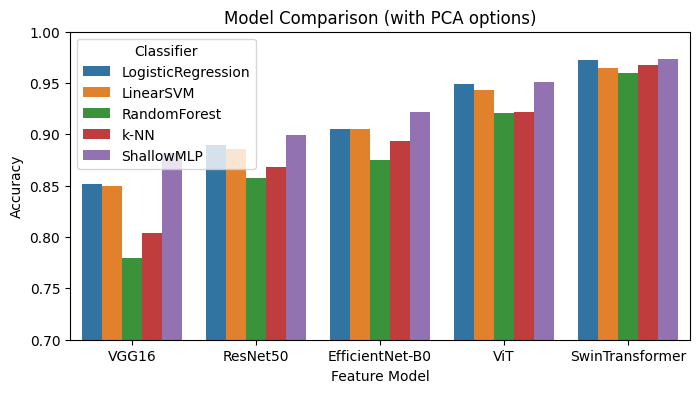

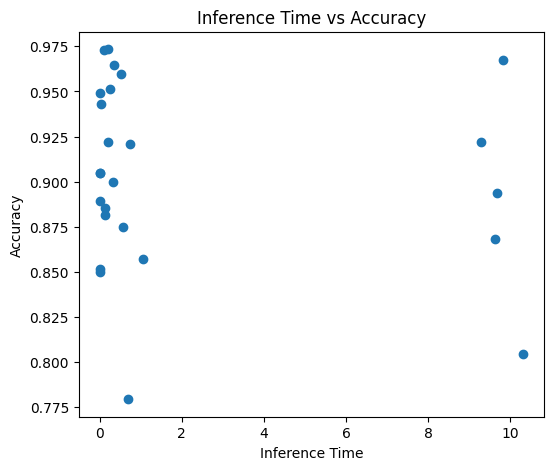

In [42]:
display(ui)